In [1]:
# 1) Imports
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score

First, we import the libraries needed for the project. Pandas and NumPy are used for handling and analyzing the dataset, Matplotlib for visualization, and scikit-learn provides tools for data splitting, preprocessing, training machine learning models, and evaluating their performance.

In [2]:
# 2) Loading dataset
DATA_PATH = Path('final_processed_dataset_V2.csv')
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"
df = pd.read_csv(DATA_PATH)
print("Loaded", df.shape)
print("Columns:", df.columns.tolist())

Loaded (4200, 10)
Columns: ['acousticness', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'instrumentalness', 'track_popularity', 'is_hit']


Next, we load the dataset into a pandas DataFrame so it can be analyzed and processed. The code also checks whether the file exists to avoid errors and prints the dataset shape and column names to get a quick overview of the data structure.

In [3]:
# 3) Creating target: hit if popularity > 50
cutoff = 50
if 'track_popularity' not in df.columns:
    raise ValueError("Dataset must have column 'track_popularity'")
df['is_hit'] = (df['track_popularity'] > cutoff).astype(int)
print("Using cutoff:", cutoff)
print(df['is_hit'].value_counts())

Using cutoff: 50
is_hit
0    2212
1    1988
Name: count, dtype: int64


Next, we create the target variable for the model. A song is labeled as a hit if its popularity score is greater than 50, otherwise it is labeled as not a hit. This converts the popularity score into a binary variable (is_hit), which is required for classification models.

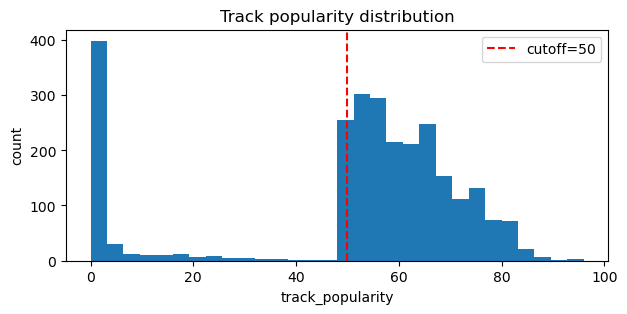

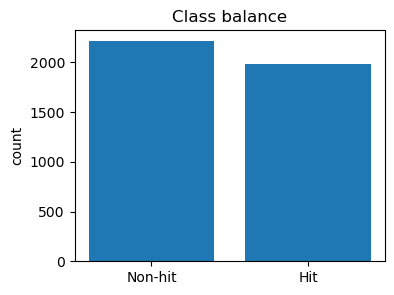

In [4]:
# 4) Small EDA: popularity histogram and class balance
plt.figure(figsize=(7,3))
plt.hist(df['track_popularity'].dropna(), bins=30)
plt.axvline(cutoff, color='red', linestyle='--', label=f'cutoff={cutoff}')
plt.title('Track popularity distribution')
plt.xlabel('track_popularity'); plt.ylabel('count'); plt.legend()
plt.show()

plt.figure(figsize=(4,3))
counts = df['is_hit'].value_counts().sort_index()
plt.bar(['Non-hit','Hit'], counts.values)
plt.title('Class balance'); plt.ylabel('count')
plt.show()

Next, we perform a small exploratory data analysis (EDA). We visualize the distribution of track popularity and the class balance between hits and non-hits to better understand the dataset and check whether the target variable is balanced.

In [5]:
# 5) common Spotify audio features
features = ['acousticness','danceability','energy','valence','tempo','loudness','speechiness','instrumentalness']
features = [c for c in features if c in df.columns]
if not features:
    # fallback to numeric columns except popularity & target
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    features = [c for c in numeric_cols if c not in ('track_popularity','is_hit')]
print("Using features:", features)

X = df[features].copy()
y = df['is_hit'].copy()

Using features: ['acousticness', 'danceability', 'energy', 'valence', 'tempo', 'loudness', 'speechiness', 'instrumentalness']


Next, we select the Spotify audio features that will be used as input variables for the model. These features describe characteristics of the songs (such as danceability, energy, and tempo) that may help predict whether a song becomes a hit. The features are stored in X, while the target variable (is_hit) is stored in y.

In [6]:
# 6) Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train/test shapes:", X_train.shape, X_test.shape)

Train/test shapes: (3360, 8) (840, 8)


Next, we split the dataset into training and testing sets. The training data is used to train the model, while the test data is used to evaluate its performance. Stratified splitting is used to keep the same proportion of hits and non-hits in both sets.

In [7]:
# 7) Simple kNN pipeline + small grid search (quick)
pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier())])
param_grid = {
    'knn__n_neighbors': list(range(1,16)),   # smaller range for speed
    'knn__weights': ['uniform','distance'],
    'knn__p': [1,2]
}
cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
gs = GridSearchCV(pipe, param_grid, cv=cv, scoring='f1', n_jobs=-1, verbose=0)
gs.fit(X_train, y_train)

print("Best params:", gs.best_params_)
print("Best CV F1:", gs.best_score_)

best_knn = gs.best_estimator_

Best params: {'knn__n_neighbors': 15, 'knn__p': 1, 'knn__weights': 'distance'}
Best CV F1: 0.6625330949678857


Next, we build a k-Nearest Neighbors (kNN) pipeline with feature scaling and perform a grid search to find the best hyperparameters. Scaling ensures all features contribute equally to distance calculations, and the grid search tests different numbers of neighbors, distance metrics, and weighting schemes. Stratified cross-validation is used to reliably evaluate performance on the training set. The best model is saved for later evaluation.

In [8]:
# 8) Evaluating kNN on test set
y_pred = best_knn.predict(X_test)
y_proba = best_knn.predict_proba(X_test)[:,1] if hasattr(best_knn, 'predict_proba') else None

print("=== kNN Test classification report ===")
print(classification_report(y_test, y_pred))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
if y_proba is not None:
    print("ROC AUC:", roc_auc_score(y_test, y_proba))

=== kNN Test classification report ===
              precision    recall  f1-score   support

           0       0.71      0.57      0.63       442
           1       0.61      0.74      0.67       398

    accuracy                           0.65       840
   macro avg       0.66      0.65      0.65       840
weighted avg       0.66      0.65      0.65       840

Confusion matrix:
 [[250 192]
 [102 296]]
ROC AUC: 0.7115299347415812


Next, we evaluate the kNN model on the test set to measure its performance on unseen data. We generate predictions, calculate a classification report, and display the confusion matrix to understand how well hits and non-hits are classified. If available, the ROC AUC score is also computed to assess the model’s ability to distinguish between the two classes.

## Results kNN Model

The k-Nearest Neighbors model achieved an accuracy of 65% on the test set.  
The ROC AUC score was 0.71, indicating moderate predictive performance.

The confusion matrix shows that the model correctly identified 296 of 398 true hits (recall ≈ 74.4%) but also produced 192 false positives. This means the model tends to classify many songs as hits even when they are not.

Overall, the kNN model performs reasonably well at detecting hits but has limited precision.

In [9]:
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

Next, we import additional tools for building and evaluating other machine learning models. Logistic Regression and Random Forest will allow us to compare different approaches, while the metrics functions provide ways to measure model performance in terms of accuracy, precision, recall, F1 score, and ROC AUC.

In [10]:
# 9) Quick compare: Logistic Regression and Random Forest
models = {
    'kNN': best_knn,
    'LogReg': make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=42)),
    'RF': make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42))
}
# fit LR and RF
models['LogReg'].fit(X_train, y_train)
models['RF'].fit(X_train, y_train)

print("\nModel comparison (accuracy, precision, recall, f1, roc_auc):")
rows = []
for name, m in models.items():
    ypr = m.predict(X_test)
    yprob = m.predict_proba(X_test)[:,1] if hasattr(m, 'predict_proba') else None
    auc = roc_auc_score(y_test, yprob) if yprob is not None else None
    rows.append((name, accuracy_score(y_test, ypr), 
                 # precision/recall with zero_division guard
                 precision_score(y_test, ypr, zero_division=0),
                 recall_score(y_test, ypr, zero_division=0),
                 f1_score(y_test, ypr, zero_division=0),
                 auc))
comp = pd.DataFrame(rows, columns=['model','accuracy','precision','recall','f1','roc_auc'])
print(comp.to_string(index=False))



Model comparison (accuracy, precision, recall, f1, roc_auc):
 model  accuracy  precision   recall       f1  roc_auc
   kNN  0.650000   0.606557 0.743719 0.668172  0.71153
LogReg  0.659524   0.620690 0.723618 0.668213  0.71857
    RF  0.683333   0.654930 0.701005 0.677184  0.74255


Next, we compare the performance of three models: kNN, Logistic Regression, and Random Forest. Each model is trained on the same training data, and key metrics accuracy, precision, recall, F1 score, and ROC AUC are calculated on the test set. This allows us to see which model performs best for predicting hits and informs decisions for further improvements.

## Limitations & Next Steps

### Limitations
- Missing non-audio factors: The dataset only includes audio features such as danceability, energy, and valence. However, real-world music popularity is heavily influenced by external factors such as artist popularity, marketing campaigns, playlist placement, social media trends, and timing of release. Because these variables are absent, the model cannot fully explain why certain tracks become hits.

- Arbitrary popularity threshold: The binary label `is_hit = (track_popularity > 50)` simplifies popularity into two categories. While useful for classification, this threshold is somewhat arbitrary and different cutoffs (e.g., 60 or 75) could change the model's results.

- Feature limitations: Audio features may not capture higher-level musical characteristics such as lyrical content, genre trends, or emotional context.

- Model limitations: The kNN model is sensitive to feature scaling and can become computationally expensive as the dataset grows.

### Next Steps
1. Use Random Forest as the main model.
2. Add additional metadata features such as artist popularity or playlist placements.
3. Include lyrical or textual features using NLP methods.
4. Test different popularity thresholds (50, 60, 75).
5. Use temporal validation to simulate real-world predictions.

In [11]:
# Installing packages 
%pip install rapidfuzz scikit-learn pandas numpy nltk

Note: you may need to restart the kernel to use updated packages.


Here, we install the required Python packages needed for the analysis. These include pandas and NumPy for data handling, scikit-learn for machine learning, nltk for text processing, and rapidfuzz for fast string matching, ensuring all dependencies are available before running the notebook.

In [12]:
# Loading CSVs
import pandas as pd
from pathlib import Path

# paths 
lyrics_path = Path("song_lyrics.csv")       
spotify_path = Path("SpotifyFeatures.csv")  

assert lyrics_path.exists(), f"Can't find {lyrics_path}"
assert spotify_path.exists(), f"Can't find {spotify_path}"

df_lyrics = pd.read_csv(lyrics_path)
df_sp = pd.read_csv(spotify_path)

print("Lyrics rows:", df_lyrics.shape)
print("Spotify rows:", df_sp.shape)
print("Lyrics columns:", df_lyrics.columns.tolist())
print("Spotify columns:", df_sp.columns.tolist())

# peek
display(df_lyrics.head())
display(df_sp.head())

Lyrics rows: (5134856, 11)
Spotify rows: (232725, 18)
Lyrics columns: ['title', 'tag', 'artist', 'year', 'views', 'features', 'lyrics', 'id', 'language_cld3', 'language_ft', 'language']
Spotify columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


,title,tag,artist,year,views,features,lyrics,id,language_cld3,language_ft,language
0,Killa Cam,rap,Cam'ron,2004,173166,"{""Cam\\'ron"",""Opera Steve""}","[Chorus: Opera Steve & Cam'ron]\nKilla Cam, Ki...",1,en,en,en
1,Can I Live,rap,JAY-Z,1996,468624,{},"[Produced by Irv Gotti]\n\n[Intro]\nYeah, hah,...",3,en,en,en
2,Forgive Me Father,rap,Fabolous,2003,4743,{},Maybe cause I'm eatin\nAnd these bastards fien...,4,en,en,en
3,Down and Out,rap,Cam'ron,2004,144404,"{""Cam\\'ron"",""Kanye West"",""Syleena Johnson""}",[Produced by Kanye West and Brian Miller]\n\n[...,5,en,en,en
4,Fly In,rap,Lil Wayne,2005,78271,{},"[Intro]\nSo they ask me\n""Young boy\nWhat you ...",6,en,en,en


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


Next, we load the two datasets song lyrics and Spotify audio features into pandas DataFrames. The code checks that the files exist to prevent errors and prints the shape and columns of each dataset to get a quick overview. Displaying the first few rows helps to inspect the data and understand its structure before further processing.

In [13]:
#Normalizing/renaming columns for consistent merging
import re
def clean_text(s):
    if pd.isna(s):
        return ""
    s = str(s).lower()
    s = s.strip()
    # removing content in parentheses/brackets and "feat." parts
    s = re.sub(r"\(.*?\)|\[.*?\]|feat\.?.*|ft\.?.*", "", s)
    # removing punctuation
    s = re.sub(r"[^\w\s]", "", s)
    # collapsing spaces
    s = re.sub(r"\s+", " ", s)
    return s.strip()

# standardizing column names to use
# for lyrics df: title, artist
df_lyrics = df_lyrics.rename(columns={
    "title": "track_name",
    "artist": "artist_name"
})

# For spotify CSV: ensuring columns have expected names 
df_sp = df_sp.rename(columns={
    "track_name": "track_name",
    "artist_name": "artist_name",
    "popularity": "track_popularity"
})

# creating cleaned keys
df_lyrics["artist_clean"] = df_lyrics["artist_name"].astype(str).map(clean_text)
df_lyrics["track_clean"] = df_lyrics["track_name"].astype(str).map(clean_text)

df_sp["artist_clean"] = df_sp["artist_name"].astype(str).map(clean_text)
df_sp["track_clean"] = df_sp["track_name"].astype(str).map(clean_text)

Next, we clean and standardize the text columns to prepare for merging the datasets. This includes normalizing names by lowercasing, removing punctuation, parentheses, and featuring info, and collapsing extra spaces. Consistent column names and cleaned keys for tracks and artists ensure accurate matching between the lyrics and Spotify feature datasets.

In [14]:
# removing duplicates in lyrics dataset
df_lyrics = df_lyrics.drop_duplicates(subset=["artist_clean","track_clean"])

# now merging
merged_exact = df_sp.merge(
    df_lyrics[["track_clean","artist_clean","lyrics"]],
    on=["artist_clean","track_clean"],
    how="left"
)

print("Merged rows:", merged_exact.shape)
print("Songs with lyrics:", merged_exact["lyrics"].notna().sum())

Merged rows: (232725, 21)
Songs with lyrics: 128935


Next, we remove duplicate songs in the lyrics dataset to avoid multiple matches during merging. We then merge the Spotify features with the lyrics using the cleaned artist and track names. This creates a combined dataset where each song has both audio features and lyrics, and we check how many songs successfully include lyrics.

In [15]:
merged_exact = merged_exact.drop_duplicates(subset=["artist_name","track_name"])

In [16]:
# removing duplicates
df_lyrics = df_lyrics.drop_duplicates(subset=["artist_clean","track_clean"])

# merging spotify + lyrics
merged_exact = df_sp.merge(
    df_lyrics[["artist_clean","track_clean","lyrics"]],
    on=["artist_clean","track_clean"],
    how="left"
)

print("Merged rows:", merged_exact.shape)
print("Songs with lyrics:", merged_exact["lyrics"].notna().sum())

Merged rows: (232725, 21)
Songs with lyrics: 128935


Here, we remove duplicate entries in the lyrics dataset and merge it with the Spotify features using the cleaned artist and track names. This results in a combined dataset containing both audio features and lyrics, and we check how many songs have associated lyrics after the merge.

In [19]:
#Creating the binary target and saving merged dataset
# defining is_hit
merged_exact['is_hit'] = (merged_exact['track_popularity'] > 50).astype(int)

# keeping columns relevant for modeling
model_columns = [
    'track_id', 'artist_name','track_name','track_popularity','is_hit',
    # audio features (keep if present)
    'acousticness','danceability','energy','valence','tempo','loudness',
    'speechiness','instrumentalness','duration_ms','genre','mode'
]
# only keeping columns present
model_columns = [c for c in model_columns if c in merged_exact.columns]
df_model = merged_exact[model_columns + ['lyrics']].copy()

# basic stats
print("Final dataset shape:", df_model.shape)
print("Has lyrics:", df_model['lyrics'].notna().sum(), "rows")
print("Class balance (is_hit):")
print(df_model['is_hit'].value_counts())

# saving to disk
output_path = Path("merged_spotify_lyrics_model.csv")
try:
    df_model.to_csv(output_path, index=False)
    print(f"Saved {output_path}")
except PermissionError:
    fallback_path = Path(f"merged_spotify_lyrics_model_{pd.Timestamp.now().strftime('%Y%m%d_%H%M%S')}.csv")
    df_model.to_csv(fallback_path, index=False)
    print(f"Could not write to {output_path} (file may be open). Saved to {fallback_path} instead.")

Final dataset shape: (232725, 17)
Has lyrics: 128935 rows
Class balance (is_hit):
is_hit
0    153123
1     79602
Name: count, dtype: int64
Could not write to merged_spotify_lyrics_model.csv (file may be open). Saved to merged_spotify_lyrics_model_20260315_210019.csv instead.


Next, we create the binary target is_hit based on track popularity and select the relevant columns for modeling, including audio features, metadata, and lyrics. We inspect basic statistics like dataset shape, presence of lyrics, and class balance, then save the cleaned and merged dataset to a CSV file for later use in modeling.

In [27]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score

# replacing missing lyrics
df_model["lyrics"] = df_model["lyrics"].fillna("")

# preparing leakage-safe X and y
y = df_model['is_hit'].copy()
X = df_model.drop(columns=[c for c in ['is_hit', 'track_popularity'] if c in df_model.columns]).copy()

cols_audio = [c for c in ['acousticness','danceability','energy','valence','tempo','loudness','speechiness','instrumentalness','duration_ms'] if c in X.columns]

# training/testing split (only on leakage-safe features)
X_train_a, X_test_a, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ColumnTransformer: audio pipeline and text pipeline
audio_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Text pipeline: TF-IDF -> SVD 
text_pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=20000, stop_words='english', ngram_range=(1,2))),
    ('svd', TruncatedSVD(n_components=100, random_state=42))
])

preprocessor = ColumnTransformer([
    ('audio', audio_pipeline, cols_audio),
    ('lyrics', text_pipeline, 'lyrics')
], remainder='drop')

clf = Pipeline([
    ('pre', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1))
])

# Fitting 
clf.fit(X_train_a, y_train)

# Evaluating
from sklearn.metrics import classification_report, roc_auc_score
y_pred = clf.predict(X_test_a)
y_proba = clf.predict_proba(X_test_a)[:,1]
print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     30625
           1       0.87      0.78      0.83     15920

    accuracy                           0.89     46545
   macro avg       0.88      0.86      0.87     46545
weighted avg       0.89      0.89      0.89     46545

ROC AUC: 0.9317671336273202


Next, we build a model that uses both audio features and song lyrics to predict hits. Audio features are cleaned and scaled, while lyrics are converted into numbers using TF-IDF and reduced with SVD. These are combined and fed into a Random Forest classifier, which is trained on the training set and tested on the test set. We then check how well the model performs using classification scores and ROC AUC.

In [21]:
clf.fit(X_train_a, y_train)

,steps,"[('pre', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('audio', ...), ('lyrics', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Here, we train the pipeline on the training data. This step fits the preprocessing for audio and lyrics and trains the Random Forest model to learn patterns that help predict whether a song is a hit.

In [28]:
y_pred = clf.predict(X_test_a)
y_proba = clf.predict_proba(X_test_a)[:,1]

from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.94      0.92     30625
           1       0.87      0.78      0.83     15920

    accuracy                           0.89     46545
   macro avg       0.88      0.86      0.87     46545
weighted avg       0.89      0.89      0.89     46545

ROC AUC: 0.9317671264485694
Confusion matrix:
[[28771  1854]
 [ 3423 12497]]


Here, we use the trained model to make predictions on the test set. We calculate the predicted classes and probabilities, then evaluate the model’s performance with a classification report, ROC AUC score, and confusion matrix to see how well hits and non-hits are identified.

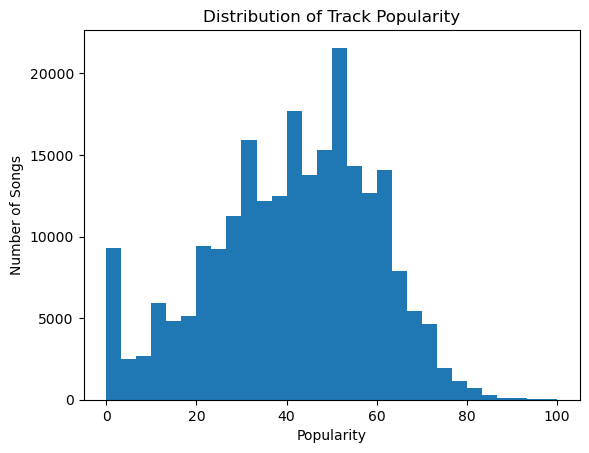

In [23]:
import matplotlib.pyplot as plt

plt.hist(df_model["track_popularity"], bins=30)
plt.title("Distribution of Track Popularity")
plt.xlabel("Popularity")
plt.ylabel("Number of Songs")
plt.show()

Here, we visualize the distribution of track popularity using a histogram. This helps us understand how popularity scores are spread across songs and whether there are many hits or mostly lower-popularity tracks in the dataset.

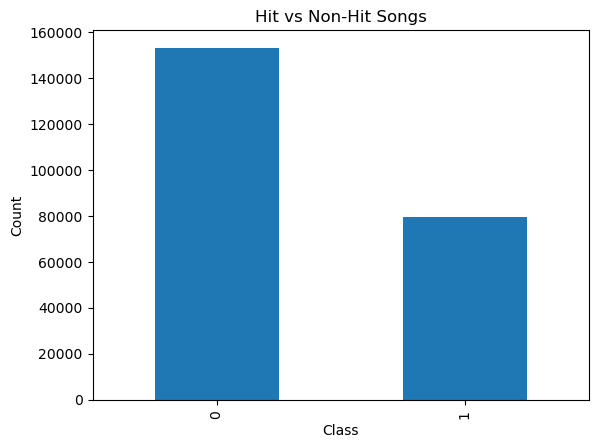

In [24]:
df_model["is_hit"].value_counts().plot(kind="bar")
plt.title("Hit vs Non-Hit Songs")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

Here, we plot a bar chart showing the number of hit and non-hit songs. This allows us to quickly see the class balance, which is important for understanding the dataset and potential challenges for the model.

Categorical features: ['genre', 'artist_name']
Class distribution (is_hit):
is_hit
0    153123
1     79602
Name: count, dtype: int64 

Train / test sizes: (186180, 15) (46545, 15)
Fitting pipeline (this may take a bit if TF-IDF is on)...

Classification report:

              precision    recall  f1-score   support

           0     0.9107    0.9458    0.9279     30625
           1     0.8874    0.8215    0.8532     15920

    accuracy                         0.9033     46545
   macro avg     0.8990    0.8837    0.8905     46545
weighted avg     0.9027    0.9033    0.9023     46545


Confusion matrix:

[[28966  1659]
 [ 2842 13078]]

ROC AUC: 0.9491


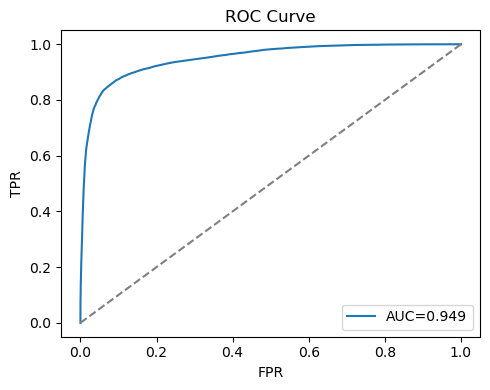

Saved pipeline to rf_pipeline_combined.joblib


In [29]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
import joblib
import matplotlib.pyplot as plt

df = pd.read_csv("merged_spotify_lyrics_model.csv")

# Configuration
USE_LYRICS = True
TEST_SIZE = 0.20
RANDOM_STATE = 42
TFIDF_MAX_FEATURES = 10000
SVD_COMPONENTS = 100
RF_N_ESTIMATORS = 200

# Ensuring required columns exist
expected_cols = ['track_id','artist_name','track_name','track_popularity','is_hit',
                 'acousticness','danceability','energy','valence','tempo','loudness',
                 'speechiness','instrumentalness','duration_ms','genre','mode','lyrics']
missing = [c for c in expected_cols if c not in df.columns]
if missing:
    print("Warning: these expected columns are missing from df:", missing)

# Preparing dataset
df_model = df.copy()

# Encode 'mode' if it contains strings like 'Major'/'Minor'
if 'mode' in df_model.columns and df_model['mode'].dtype == object:
    df_model['mode'] = df_model['mode'].map({'Major': 1, 'Minor': 0}).fillna(0).astype(int)

# Dropping rows w/o target before casting to avoid conversion errors
df_model = df_model.dropna(subset=['is_hit'])

# converting is_hit to int if needed
df_model['is_hit'] = df_model['is_hit'].astype(int)

# Numeric/audio columns
audio_cols = [c for c in ['acousticness','danceability','energy','valence','tempo',
                          'loudness','speechiness','instrumentalness','duration_ms'] if c in df_model.columns]

# track_popularity excluded because it directly defines is_hit (data leakage)
meta_cols = [c for c in ['mode'] if c in df_model.columns]

numeric_cols = audio_cols + meta_cols

# Categorical columns: genre and artist_name
cat_cols = [c for c in ['genre', 'artist_name'] if c in df_model.columns]
print("Categorical features:", cat_cols)

# Filling missing lyrics with empty string
if USE_LYRICS and 'lyrics' in df_model.columns:
    df_model['lyrics'] = df_model['lyrics'].fillna("")
else:
    USE_LYRICS = False

# Creating leakage-safe X and y
y = df_model['is_hit']
X = df_model.drop(columns=[c for c in ['is_hit', 'track_popularity'] if c in df_model.columns]).copy()

# quick class balance report
print("Class distribution (is_hit):")
print(y.value_counts(normalize=False), "\n")

# Training / Test splitting on leakage-safe features only
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)
print("Train / test sizes:", X_train.shape, X_test.shape)

# Building ColumnTransformer
numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale', StandardScaler())
])

# Categorical pipeline: use sparse OHE to avoid huge dense matrix allocation
cat_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='constant', fill_value='unknown')),
    ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=True, min_frequency=10, dtype=np.float32))
])

transformers = []
if numeric_cols:
    transformers.append(('num', numeric_pipeline, numeric_cols))
if cat_cols:
    transformers.append(('cat', cat_pipeline, cat_cols))

if USE_LYRICS and 'lyrics' in X_train.columns:
    text_pipeline = Pipeline([
        ('tfidf', TfidfVectorizer(max_features=TFIDF_MAX_FEATURES, stop_words='english', ngram_range=(1,2), dtype=np.float32)),
        ('svd', TruncatedSVD(n_components=min(SVD_COMPONENTS, TFIDF_MAX_FEATURES-1), random_state=RANDOM_STATE))
    ])
    transformers.append(('txt', text_pipeline, 'lyrics'))

preprocessor = ColumnTransformer(transformers, remainder='drop')

# Full pipeline with Random Forest
rf = RandomForestClassifier(n_estimators=RF_N_ESTIMATORS, random_state=RANDOM_STATE, n_jobs=-1, class_weight='balanced')

pipeline = Pipeline([
    ('pre', preprocessor),
    ('clf', rf)
])

# Fitting
print("Fitting pipeline (this may take a bit if TF-IDF is on)...")
pipeline.fit(X_train, y_train)

# Evaluate
y_pred = pipeline.predict(X_test)
if hasattr(pipeline, "predict_proba"):
    y_proba = pipeline.predict_proba(X_test)[:,1]
else:
    y_proba = None

print("\nClassification report:\n")
print(classification_report(y_test, y_pred, digits=4))
print("\nConfusion matrix:\n")
print(confusion_matrix(y_test, y_pred))

if y_proba is not None:
    auc = roc_auc_score(y_test, y_proba)
    print("\nROC AUC: {:.4f}".format(auc))
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(5,4))
    plt.plot(fpr,tpr,label=f'AUC={auc:.3f}')
    plt.plot([0,1],[0,1],'--',color='gray')
    plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Curve'); plt.legend(); plt.tight_layout(); plt.show()

# Saving model
joblib.dump(pipeline, "rf_pipeline_combined.joblib")
print("Saved pipeline to rf_pipeline_combined.joblib")

## What we did
The goal of this project was to predict whether a song is a **hit** or **not a hit**.

We followed these steps:

1. We combined different types of information about each song:
- audio features (for example: danceability, energy, loudness)
- metadata (for example: artist or genre-related columns)
- lyrics information (turned on/off with a switch in the notebook)

2. We cleaned and prepared the data so a model can use it:
- missing values were handled
- numeric columns were scaled (so values are on similar ranges)
- category columns were converted to numbers using one-hot encoding
- lyrics text was converted into numeric vectors using TF-IDF, then reduced with SVD

3. We started with a simple model called **kNN** (k-Nearest Neighbors):
- this model works by looking at the most similar songs and copying their label
- we automatically searched for the best settings (for example: how many neighbours to look at)
- result: 65% accuracy and a ROC AUC of 0.71

4. We compared kNN with two other models (Logistic Regression and Random Forest):
- kNN found many hits but also incorrectly labelled a lot of non-hits as hits
- Random Forest performed best overall, so it became the final model

5. We built a full machine-learning pipeline with Random Forest:
- preprocessing + model are connected in one workflow
- this avoids data leakage and keeps training/prediction consistent

6. We trained and tested the final model:
- data was split into train and test sets
- the model learned from the training set
- performance was checked on the test set using:
  - classification report
  - confusion matrix
  - ROC-AUC (when probabilities are available)

7. We saved the final trained pipeline:
- output file: `rf_pipeline_combined.joblib`

## Reflection on the model

What went well:
- starting with kNN gave us a useful baseline to compare against
- kNN was good at finding actual hits (it caught about 74% of them)
- switching to Random Forest clearly improved overall performance
- using multiple feature types (audio + metadata + lyrics) is a strong approach
- evaluation includes more than one metric, which gives a better picture than accuracy alone

Current limitations:
- kNN made many false positives — it labelled too many non-hits as hits, meaning its precision was low
- hit prediction is usually imbalanced (fewer hits than non-hits), so any model may still miss many true hits
- lyric features can be noisy and may not always improve results
- one train/test split gives only one snapshot of performance

## What can be improved next

1. Help the model notice hit songs better.
- Right now there are usually fewer hit songs than non-hit songs.
- We can adjust training so hit songs get more attention.

2. Try a few different model types.
- One model is a good start, but comparing several models usually gives better results.
- Then keep the model that performs best.

3. Make the lyrics part cleaner and clearer.
- Remove more noise from lyrics text.
- Test a few simple text settings to see what helps most.

4. Test the model in a more reliable way.
- Repeat training/testing several times, not just once.
- Keep one final test set untouched until the very end.

5. Learn from the model's mistakes.
- Look at songs the model got wrong.
- Check if mistakes happen more for certain genres, artists, or years.

In short: this is a solid end-to-end baseline system, and the next gains will likely come from better balance handling, better text preparation, and more reliable testing.